In [2]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import random
from matplotlib import pyplot as plt
from datetime import datetime
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
# 연극 csv
data = pd.read_excel('../data/raw/playTop77_star.xlsx')
data = data.drop(data.columns[0], axis=1)
data.head()

,Title,ID,Star,Date
0,연극 〈운빨로맨스〉- 대학로,seeun0***,5,2023.10.10
1,연극 〈운빨로맨스〉- 대학로,isoo9***,5,2023.10.10
2,연극 〈운빨로맨스〉- 대학로,rkgml5***,5,2023.10.09
3,연극 〈운빨로맨스〉- 대학로,da9***,5,2023.10.03
4,연극 〈운빨로맨스〉- 대학로,4322***,5,2023.09.28


In [4]:
data['Title'] = data['Title'].replace('★평점9.5★ 코미디의맛/쇼미더퍼니', '★평점9.5★ 코미디의맛_쇼미더퍼니')

In [5]:
data.to_excel("../data/raw/playTop77_star.xlsx", sheet_name='Sheet1')

In [7]:
data = pd.read_excel('../data/raw/musicalTop77_star.xlsx')
data = data.drop(data.columns[0], axis=1)
data.head()

,Title,ID,Star,Date
0,난타(NANTA) - 명동공연,zzong2***,5,2023.10.10
1,난타(NANTA) - 명동공연,zzong2***,5,2023.10.10
2,난타(NANTA) - 명동공연,bi***,5,2023.10.10
3,난타(NANTA) - 명동공연,kbw9***,5,2023.10.06
4,난타(NANTA) - 명동공연,eng***,5,2023.10.06


In [8]:
data['Title'] = data['Title'].replace('뮤지컬 〈셜록홈즈 : 앤더슨가의 비밀〉', '뮤지컬 〈셜록홈즈 _ 앤더슨가의 비밀〉')

In [9]:
data.to_excel("../data/raw/musicalTop77_star.xlsx", sheet_name='Sheet1')

In [ ]:
# 연극 csv
data = pd.read_excel('../data/raw/theater_rating_final1.xlsx')
data = data.drop(data.columns[0], axis=1)
data.head()

,Title,ID,Star,Date
0,연극 너의 목소리가 들려,darkness1***,5,2023.10.11
1,연극 너의 목소리가 들려,mangdd***,5,2023.10.10
2,연극 너의 목소리가 들려,p***,5,2023.10.10
3,연극 너의 목소리가 들려,bbb8***,5,2023.10.10
4,연극 너의 목소리가 들려,tkdkf02***,5,2023.10.09


In [ ]:
len(data)

9760

In [ ]:
n_user = len(data['ID'].unique())    # 유저 수
n_movie = len(data['Title'].unique())    # 영화 수

print('유저 수 :', n_user, '영화 수 :', n_movie)

# 평점 데이터 정보
data.info()

유저 수 : 6363 영화 수 : 40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9760 entries, 0 to 9759
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   9760 non-null   object
 1   ID      9760 non-null   object
 2   Star    9760 non-null   int64 
 3   Date    9760 non-null   object
dtypes: int64(1), object(3)
memory usage: 305.1+ KB


In [ ]:
data[['Star']].describe()

,Star
count,9760.000000
mean,4.848053
std,0.557179
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


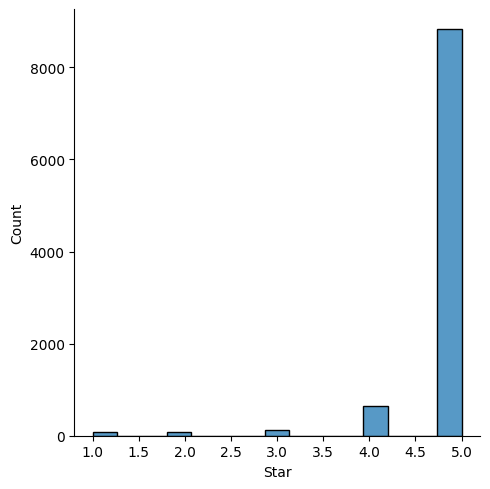

In [ ]:
sns.displot(data['Star'])

In [ ]:
movie_statistics = pd.DataFrame({
    'numUsers': data.groupby('Title')['ID'].nunique(),
    'avgRating': data.groupby('Title')['Star'].mean(),
    'stdRating': data.groupby('Title')['Star'].std()
}).reset_index()

movie_statistics

,Title,numUsers,avgRating,stdRating
0,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,22,5.000000,0.000000
1,(리얼타임 코믹연극) 택시안에서 - 부산,35,4.767442,0.718371
2,(리얼타임 코믹연극) 택시안에서 - 서울,144,4.744076,0.648001
3,(코믹연극) 달동네-부산,13,4.928571,0.267261
4,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,431,4.819608,0.580299
5,2시간탈출 졸탄쇼,125,4.772059,0.698855
6,3대가 웃고 우는 연극 〈염쟁이 유씨〉,13,4.923077,0.277350
7,4D공포연극 〈스위치〉,337,4.955556,0.273759
8,★평점9.5★ 코미디의맛/쇼미더퍼니,294,4.764045,0.710641
9,공포스릴러연극〈두여자〉- 대구,56,5.000000,0.000000


In [ ]:
top10_df = movie_statistics.sort_values(by='numUsers', ascending=False)[:10]
top10_df.head()

,Title,numUsers,avgRating,stdRating
36,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,509,4.601639,0.873058
25,연극 〈운빨로맨스〉- 대학로,495,4.907303,0.433937
12,국민 코믹 연극 〈오백에삼십〉 - 대학로 세우아트센터 1관,487,4.896673,0.429001
31,연극〈늘근도둑이야기〉,461,4.811765,0.675024
29,연극 한뼘사이,459,4.913478,0.431086


In [ ]:
data['Title'].unique()

array(['연극 너의 목소리가 들려', '대학로 1위 연극 〈쉬어매드니스〉', '행오버', '연극 한뼘사이',
       '연극〈늘근도둑이야기〉', '뮤직드라마 〈불편한 편의점〉', '코믹감동 휴먼판타지 연극 〈2호선 세입자〉',
       '10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀', '좀비연극 오마이갓', '연극 핫식스',
       '［서울 대학로］연극 라면', '연극 죽여주는 이야기', '연극 〈카페 쥬에네스〉', '연극 〈운빨로맨스〉- 대학로',
       '4D공포연극 〈스위치〉', '연극 〈수상한흥신소〉', '국민 코믹 연극 〈오백에삼십〉 - 대학로 세우아트센터 1관',
       '［2023 SPAF］ 극단 돌파구 〈지상의 여자들〉', '진짜나쁜소녀', '연극 〈뷰티풀라이프〉',
       '★평점9.5★ 코미디의맛/쇼미더퍼니', '이머시브씨어터 카지노', '코미디 연극〈딜리버리〉', '연극 〈굿닥터〉',
       '2시간탈출 졸탄쇼', '연극 〈극적인 하룻밤〉', '연극 〈나의PS파트너〉', '공포연극 ［자취］',
       '!로맨틱코미디 연극〈운빨로맨스〉! - 대구', '대학로 청소년연극 〈사춘기메들리〉',
       '(리얼타임 코믹연극) 택시안에서 - 부산', '(리얼타임 코믹연극) 택시안에서 - 서울',
       '(코믹연극) 달동네-부산', '3대가 웃고 우는 연극 〈염쟁이 유씨〉', '공포스릴러연극〈두여자〉- 대구',
       '공포연극 조각', '그곳에 있었다', '나의 장례식에 와줘', '로맨틱코미디 〈슬기로운 신혼생활〉',
       '모든 날 모든 순간'], dtype=object)

## 장르

In [ ]:
play = pd.read_excel('/content/drive/MyDrive/캡스톤/theater_merged.xlsx')
play = play.drop(play.columns[0], axis=1)
play = play.drop(play.columns[2], axis=1)
play.head()

,Title,Text_clear_num,공연소개,장르
0,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,운빨 로맨스 으릉 점에 살고 점에 죽는 점보늬의 오랑 남자와 하롯밤 프로젝트 목숨이...,NaN,"로맨스, 코믹"
1,(리얼타임 코믹연극) 택시안에서 - 부산,웃음 감동 사랑이 시작되는 리얼타엄 코믹연극 공연시간 투 콩감백배 다양한에피소드와 ...,NaN,"코믹, 로맨스"
2,(리얼타임 코믹연극) 택시안에서 - 서울,변 웃음 감동 사랑이 시작되는 리얼타엄 코믹연극 씨해바라기 공연시간 광일 뽀 계묵주...,NaN,"코믹, 로맨스"
3,(코믹연극) 달동네-부산,전사 오픈런 부족 초대합니다 개스 테 그를 코 뻔 부 토사 사으소시 서사으 냈 이거...,NaN,"코믹, 감동, 드라마"
4,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,가을 바람 살학살항 로맨틱 연숙 위인데 단하나의첨춘로맨스 배트 토니 잘 랄라 목탑방...,"서울 종로구 창신동, 보증금 500-월세 30!\n서울 시내가 다 보이는 옥탑방!\...","로맨스, 코믹"


In [ ]:
play['장르']

0          로맨스, 코믹
1          코믹, 로맨스
2          코믹, 로맨스
3      코믹, 감동, 드라마
4          로맨스, 코믹
          ...     
151            역사극
152            로맨스
153            역사극
154       판타지, 드라마
155            드라마
Name: 장르, Length: 156, dtype: object

In [ ]:
# '코미디' -> '코믹' 으로 변경
play['장르'] = play['장르'].str.replace('코미디', '코믹')

In [ ]:
from sklearn.preprocessing import LabelEncoder

genres = ['로맨스', '공포', '판타지', '코믹', '종교', '스릴러', '미스터리', '액션', '감동', '드라마', '역사극', '성인용']

label_encoder = LabelEncoder()

encoded_genres = label_encoder.fit_transform(genres)

genre_mapping = dict(zip(genres, encoded_genres))

print("Encoded Genres:", encoded_genres)
print("Genre Mapping:", genre_mapping)

Encoded Genres: [ 3  1 11 10  9  6  4  7  0  2  8  5]
Genre Mapping: {'로맨스': 3, '공포': 1, '판타지': 11, '코믹': 10, '종교': 9, '스릴러': 6, '미스터리': 4, '액션': 7, '감동': 0, '드라마': 2, '역사극': 8, '성인용': 5}


In [ ]:
genre_mapping = {
    '감동': 0,
    '공포': 1,
    '드라마': 2,
    '로맨스': 3,
    '미스터리': 4,
    '성인용': 5,
    '스릴러': 6,
    '액션': 7,
    '역사극': 8,
    '종교': 9,
    '코믹': 10,
    '판타지': 11
}

# 장르를 숫자로 인코딩한  장르_e 변수 생성
play['장르_e'] = play['장르'].apply(lambda x: [genre_mapping.get(genre, -1) for genre in x.split(', ')])

In [ ]:
play.head(5)

,Title,Text_clear_num,공연소개,장르,장르_e
0,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,운빨 로맨스 으릉 점에 살고 점에 죽는 점보늬의 오랑 남자와 하롯밤 프로젝트 목숨이...,NaN,"로맨스, 코믹","[3, 10]"
1,(리얼타임 코믹연극) 택시안에서 - 부산,웃음 감동 사랑이 시작되는 리얼타엄 코믹연극 공연시간 투 콩감백배 다양한에피소드와 ...,NaN,"코믹, 로맨스","[10, 3]"
2,(리얼타임 코믹연극) 택시안에서 - 서울,변 웃음 감동 사랑이 시작되는 리얼타엄 코믹연극 씨해바라기 공연시간 광일 뽀 계묵주...,NaN,"코믹, 로맨스","[10, 3]"
3,(코믹연극) 달동네-부산,전사 오픈런 부족 초대합니다 개스 테 그를 코 뻔 부 토사 사으소시 서사으 냈 이거...,NaN,"코믹, 감동, 드라마","[10, 0, 2]"
4,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,가을 바람 살학살항 로맨틱 연숙 위인데 단하나의첨춘로맨스 배트 토니 잘 랄라 목탑방...,"서울 종로구 창신동, 보증금 500-월세 30!\n서울 시내가 다 보이는 옥탑방!\...","로맨스, 코믹","[3, 10]"


In [ ]:
# 인코딩이 제대로 안 된 연극이 있는지 확인

genres = play['장르']

count_of_ones = 0

print("Count of 1s:", count_of_ones)

Count of 1s: 0


In [ ]:
## 장르 인코딩 - 원데이터 합치기

In [ ]:
data_f = pd.merge(data, play[['Title', '장르', '장르_e']], on='Title')

data['장르'] = data_f['장르']
data['장르_e'] = data_f['장르_e']
data.head(3)

,Title,ID,Star,Date,장르,장르_e
0,연극 너의 목소리가 들려,darkness1***,5,2023.10.11,"코믹, 스릴러, 미스터리","[10, 6, 4]"
1,연극 너의 목소리가 들려,mangdd***,5,2023.10.10,"코믹, 스릴러, 미스터리","[10, 6, 4]"
2,연극 너의 목소리가 들려,p***,5,2023.10.10,"코믹, 스릴러, 미스터리","[10, 6, 4]"


In [ ]:
data.to_excel("../data/raw/theater_rating_final2.xlsx", sheet_name='Sheet1')

## Steam Rating


In [ ]:
# 리뷰 수에 따라 점수를 보정하는 방법
# 기준이 되는 점수가 3점인 것 (전체 평점 또는 중앙값 사용)

In [ ]:
# SteamRating이 높은 순서대로 정렬

movie_statistics['steamRating'] = movie_statistics['avgRating'] - (movie_statistics['avgRating'] - 3.0) \
                                  * np.power(2, -np.log10(movie_statistics['numUsers']))
top10_df = movie_statistics.sort_values(by = 'steamRating', ascending=False)[:10]
pd.merge(top10_df, data[['Title', 'Date']], how='inner', on ='Title')

,Title,numUsers,avgRating,stdRating,steamRating,Date
0,연극 너의 목소리가 들려,310,4.986301,0.116370,4.633061,2023.10.11
1,연극 너의 목소리가 들려,310,4.986301,0.116370,4.633061,2023.10.10
2,연극 너의 목소리가 들려,310,4.986301,0.116370,4.633061,2023.10.10
3,연극 너의 목소리가 들려,310,4.986301,0.116370,4.633061,2023.10.10
4,연극 너의 목소리가 들려,310,4.986301,0.116370,4.633061,2023.10.09
...,...,...,...,...,...,...
4838,연극 핫식스,234,4.967626,0.273423,4.586790,2023.04.10
4839,연극 핫식스,234,4.967626,0.273423,4.586790,2023.04.10
4840,연극 핫식스,234,4.967626,0.273423,4.586790,2023.04.09
4841,연극 핫식스,234,4.967626,0.273423,4.586790,2023.04.07


## 아이디별 전처리

In [ ]:
data.head(3)

,Title,ID,Star,Date
0,연극 너의 목소리가 들려,darkness1***,5,2023.10.11
1,연극 너의 목소리가 들려,mangdd***,5,2023.10.10
2,연극 너의 목소리가 들려,p***,5,2023.10.10


In [ ]:
data.groupby('ID')['Title'].nunique()

ID
***            21
005***          2
007***          1
01023712***     1
01051868***     1
               ..
zzyouz***       3
zzz0211***      1
zzz50***        1
zzzjsi2***      1
zzzzz8***       1
Name: Title, Length: 6363, dtype: int64

In [ ]:
count_data = data.groupby(['ID','Title']).size().reset_index(name='Count')
merged_data = count_data.groupby('ID')['Title'].apply(', '.join).reset_index()
merged_data['Count'] = count_data.groupby('ID')['Count'].sum().values

merged_data

,ID,Title,Count
0,***,"(리얼타임 코믹연극) 택시안에서 - 부산, (리얼타임 코믹연극) 택시안에서 - 서울...",249
1,005***,"연극 〈운빨로맨스〉- 대학로, 연극 죽여주는 이야기",4
2,007***,2시간탈출 졸탄쇼,1
3,01023712***,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,1
4,01051868***,연극〈늘근도둑이야기〉,1
...,...,...,...
6358,zzyouz***,"진짜나쁜소녀, 코믹감동 휴먼판타지 연극 〈2호선 세입자〉, 행오버",3
6359,zzz0211***,★평점9.5★ 코미디의맛/쇼미더퍼니,1
6360,zzz50***,［서울 대학로］연극 라면,1
6361,zzzjsi2***,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,1


In [ ]:
# ID 별로 2번 이상 본 사람들
merged_data[merged_data['Count'] >= 2]

,ID,Title,Count
0,***,"(리얼타임 코믹연극) 택시안에서 - 부산, (리얼타임 코믹연극) 택시안에서 - 서울...",249
1,005***,"연극 〈운빨로맨스〉- 대학로, 연극 죽여주는 이야기",4
12,0305ji***,"10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀, 연극 〈수상한흥신소〉",2
16,0506h***,"4D공포연극 〈스위치〉, 좀비연극 오마이갓",2
26,081***,"(리얼타임 코믹연극) 택시안에서 - 서울, 연극〈늘근도둑이야기〉",2
...,...,...,...
6335,zmf***,"연극 너의 목소리가 들려, 좀비연극 오마이갓",3
6342,zororolon***,연극 〈뷰티풀라이프〉,2
6345,zunba1***,"연극 핫식스, 코믹감동 휴먼판타지 연극 〈2호선 세입자〉",2
6357,zzo***,"10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀, 코믹감동 휴먼판타지 연극 〈2호선 ...",2


In [ ]:
counted_data = data.groupby(['Title', 'ID']).size().reset_index(name='Count')
counted_data

,Title,ID,Count
0,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,J3024***,1
1,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,achiev***,1
2,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,bapa***,1
3,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,bon1***,1
4,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,bubu1***,1
...,...,...,...
7560,［서울 대학로］연극 라면,zeno***,1
7561,［서울 대학로］연극 라면,zim0***,1
7562,［서울 대학로］연극 라면,zzang6***,1
7563,［서울 대학로］연극 라면,zzinb***,1


In [ ]:
# 한 연극을 2번 이상 본 사람들의 집합 (작 기준)
counted_data[counted_data['Count'] >= 2]

,Title,ID,Count
22,(리얼타임 코믹연극) 택시안에서 - 부산,***,8
49,(리얼타임 코믹연극) 택시안에서 - 부산,moonhac***,2
57,(리얼타임 코믹연극) 택시안에서 - 서울,***,30
81,(리얼타임 코믹연극) 택시안에서 - 서울,cutey***,2
82,(리얼타임 코믹연극) 택시안에서 - 서울,dawoo***,2
...,...,...,...
7492,［서울 대학로］연극 라면,sso5***,2
7496,［서울 대학로］연극 라면,summer8***,2
7506,［서울 대학로］연극 라면,th***,2
7527,［서울 대학로］연극 라면,vkrwl***,2


In [ ]:
data.head(3)

,Title,ID,Star,Date,Exists
0,연극 너의 목소리가 들려,darkness1***,5,2023.10.11,1
1,연극 너의 목소리가 들려,mangdd***,5,2023.10.10,1
2,연극 너의 목소리가 들려,p***,5,2023.10.10,1


In [ ]:
data['Exists'] = 1

# 데이터프레임을 그룹화하고 각 연극 몇 번 봤는지 횟수를 계산
grouped_data = data.groupby(['ID', 'Title'])['Exists'].sum().unstack(fill_value=0)
grouped_data

Title,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,(리얼타임 코믹연극) 택시안에서 - 부산,(리얼타임 코믹연극) 택시안에서 - 서울,(코믹연극) 달동네-부산,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2시간탈출 졸탄쇼,3대가 웃고 우는 연극 〈염쟁이 유씨〉,4D공포연극 〈스위치〉,★평점9.5★ 코미디의맛/쇼미더퍼니,공포스릴러연극〈두여자〉- 대구,...,연극 핫식스,연극〈늘근도둑이야기〉,이머시브씨어터 카지노,좀비연극 오마이갓,진짜나쁜소녀,코미디 연극〈딜리버리〉,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,행오버,［2023 SPAF］ 극단 돌파구 〈지상의 여자들〉,［서울 대학로］연극 라면
ID,,,,,,,,,,,,,,,,,,,,,
***,0,8,30,1,5,5,0,1,52,5,...,2,2,0,0,0,0,1,1,0,0
005***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
007***,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01023712***,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01051868***,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzyouz***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0
zzz0211***,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
zzz50***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# 2번 이상 본 사람들의 ID와 결합해서 2번 이상 본 사람들로만 구성
filtered_data = merged_data[merged_data['Count'] >= 2]
filtered_data = filtered_data.drop(filtered_data.index[0])
result = grouped_data[grouped_data.index.isin(filtered_data['ID'])]

result

Title,!로맨틱코미디 연극〈운빨로맨스〉! - 대구,(리얼타임 코믹연극) 택시안에서 - 부산,(리얼타임 코믹연극) 택시안에서 - 서울,(코믹연극) 달동네-부산,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2시간탈출 졸탄쇼,3대가 웃고 우는 연극 〈염쟁이 유씨〉,4D공포연극 〈스위치〉,★평점9.5★ 코미디의맛/쇼미더퍼니,공포스릴러연극〈두여자〉- 대구,...,연극 핫식스,연극〈늘근도둑이야기〉,이머시브씨어터 카지노,좀비연극 오마이갓,진짜나쁜소녀,코미디 연극〈딜리버리〉,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,행오버,［2023 SPAF］ 극단 돌파구 〈지상의 여자들〉,［서울 대학로］연극 라면
ID,,,,,,,,,,,,,,,,,,,,,
005***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0305ji***,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0506h***,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
081***,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1000hy***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zmf***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
zororolon***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zunba1***,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [ ]:
result.to_excel("../data/raw/theater_repeat_users.xlsx", sheet_name='Sheet1')